# Import Libraries

In [1]:
import torch
import clip
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import os

# Load CLIP Model

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model, preprocess = clip.load("ViT-B/32", device=device)

print(device)

cpu


# Load Image Embeddings

In [3]:
embeddings = np.load("../data/embeddings/image_embeddings.npy")

print(embeddings.shape)

(9599, 512)


In [4]:
mapping_df = pd.read_csv("../data/embeddings/image_mapping.csv")

mapping_df.head()

,image_name
0,0.jpg
1,1.jpg
2,10.jpg
3,100.jpg
4,1000.jpg


# Load Product Dataset

In [5]:
products_df = pd.read_csv("../data/processed/cleaned_electronics_products.csv")

products_df.head()

,Unnamed: 0,name,main_category,sub_category,image,link,ratings,no_of_ratings,discount_price,actual_price
0,0,"Redmi 10 Power (Power Black, 8GB RAM, 128GB St...","tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/81eM15lVcJ...,https://www.amazon.in/Redmi-Power-Black-128GB-...,4.0,965,"₹10,999","₹18,999"
1,1,"OnePlus Nord CE 2 Lite 5G (Blue Tide, 6GB RAM,...","tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/71AvQd3Vzq...,https://www.amazon.in/OnePlus-Nord-Lite-128GB-...,4.3,"113,956","₹18,999","₹19,999"
2,2,OnePlus Bullets Z2 Bluetooth Wireless in Ear E...,"tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/51UhwaQXCp...,https://www.amazon.in/Oneplus-Bluetooth-Wirele...,4.2,"90,304","₹1,999","₹2,299"
3,3,"Samsung Galaxy M33 5G (Mystique Green, 6GB, 12...","tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/81I3w4J6yj...,https://www.amazon.in/Samsung-Mystique-Storage...,4.1,"24,863","₹15,999","₹24,999"
4,4,"OnePlus Nord CE 2 Lite 5G (Black Dusk, 6GB RAM...","tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/71V--WZVUI...,https://www.amazon.in/OnePlus-Nord-Black-128GB...,4.3,"113,956","₹18,999","₹19,999"


In [6]:
products_df.iloc[0]

Unnamed: 0                                                        0
name              Redmi 10 Power (Power Black, 8GB RAM, 128GB St...
main_category                                   tv, audio & cameras
sub_category                                        All Electronics
image             https://m.media-amazon.com/images/I/81eM15lVcJ...
link              https://www.amazon.in/Redmi-Power-Black-128GB-...
ratings                                                         4.0
no_of_ratings                                                   965
discount_price                                              ₹10,999
actual_price                                                ₹18,999
Name: 0, dtype: object

# Encode User Query

In [7]:
query = "wireless bluetooth earbuds"

text = clip.tokenize([query]).to(device)

with torch.no_grad():
    text_embedding = model.encode_text(text)

text_embedding = text_embedding.cpu().numpy()

print(text_embedding.shape)

(1, 512)


# Calculate Cosine Similarity

In [8]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_scores = cosine_similarity(text_embedding, embeddings)

print(similarity_scores.shape)

(1, 9599)


In [9]:
top_indices = similarity_scores[0].argsort()[-10:][::-1]

print(top_indices)

[3157 1864 8886 3589 5646 2929 6328 5945 9556 3039]


In [10]:
recommended_products = products_df.iloc[top_indices]

recommended_products[
    [
        "name",
        "discount_price",
        "ratings",
        "main_category",
        "sub_category"
    ]
]

,name,discount_price,ratings,main_category,sub_category
3157,"HP Deskjet Ink Advantage Ultra 4826 Print, Cop...","₹8,399",4.0,"tv, audio & cameras",All Electronics
1864,GLUN 11 mm Transparent HOT MELT 14 Glue Sticks...,₹193,3.9,"tv, audio & cameras",All Electronics
8886,7SEVEN® Compatible Tata Sky Remote Control Rep...,₹249,3.4,"tv, audio & cameras",All Electronics
3589,URBN 10000 mAh 20W Super Fast Charging Metal P...,₹999,3.7,"tv, audio & cameras",All Electronics
5646,"Itel MagicX Pro 4G (Wi-Fi Hotspot Tethering, 2...","₹2,499",2.9,"tv, audio & cameras",All Electronics
2929,"boAt Wave Edge with 1.85"" HD Display, Advanced...","₹2,099",3.8,"tv, audio & cameras",All Electronics
6328,"QUANTUM OTG Card Reader and Hub with Type-C, U...",₹379,3.8,"tv, audio & cameras",All Electronics
5945,CEDO Lenovo Tab M10 / M10 HD 10.1 inch TB-X505...,₹449,4.6,"tv, audio & cameras",All Electronics
9556,HP MPP 1.51 Stylus Pen Compatible for HP Spect...,"₹1,355",3.5,"tv, audio & cameras",All Electronics
3039,Amazon Basics 10000mAH Lithium Polymer 18W Fas...,₹999,3.8,"tv, audio & cameras",All Electronics


In [11]:
recommended_products = recommended_products.copy()

recommended_products["similarity_score"] = similarity_scores[0][top_indices]

recommended_products[
    [
        "name",
        "discount_price",
        "ratings",
        "similarity_score"
    ]
]

,name,discount_price,ratings,similarity_score
853,Lenovo 300 FHD Webcam with Full Stereo Dual Bu...,"₹2,599",4.1,0.334166
1214,"Apple Lightning to USB Camera Adapter, USB 3.0...",₹380,3.8,0.334127
1123,Mi USB 18W Dual Port Charger|Dual USB Port|Cer...,₹599,4.3,0.333037
630,"Camlin Brush Pens, 24 Shades",₹399,4.6,0.330482
988,Amazon Basics USB 2.0 Cable - A-Male to B-Male...,₹259,4.5,0.329515
1008,"Camel Fabrica Acrylic Ultra Color - 15ml Each,...",NaN,4.4,0.327060
587,Wipro 3 way multiplug with built in Surge Prot...,₹136,4.3,0.326158
475,"OPPO A31 (Mystery Black, 6GB RAM, 128GB Storag...","₹12,490",4.2,0.322155
657,Vantro Car Power Inverter 200W with 4 USB & 2 ...,"₹1,799",4.3,0.321784
654,TP-Link Tapo 360° 2MP 1080p Full HD Pan/Tilt H...,"₹2,599",4.2,0.321455


In [11]:
print(similarity_scores.shape)

(1, 9599)


In [2]:
import torch
import clip
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from PIL import Image
import os

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model, preprocess = clip.load("ViT-B/32", device=device)

print(device)

cpu


In [4]:
combined_embeddings = np.load(
    "../data/embeddings/combined_embeddings.npy"
)

print(combined_embeddings.shape)

(9599, 512)


In [5]:
mapping_df = pd.read_csv(
    "../data/embeddings/image_mapping.csv"
)

mapping_df.head()

,image_name
0,0.jpg
1,1.jpg
2,10.jpg
3,100.jpg
4,1000.jpg


In [12]:
mapping_df["product_index"] = (
    mapping_df["image_name"]
    .str.replace(".jpg", "", regex=False)
    .astype(int)
)

mapping_df.head()

,image_name,product_index
0,0.jpg,0
1,1.jpg,1
2,10.jpg,10
3,100.jpg,100
4,1000.jpg,1000


In [22]:
products_df = pd.read_csv(
    "../data/processed/cleaned_electronics_products.csv"
)

print(products_df.columns)

Index(['Unnamed: 0', 'name', 'main_category', 'sub_category', 'image', 'link',
       'ratings', 'no_of_ratings', 'discount_price', 'actual_price'],
      dtype='str')


In [8]:
query = "wireless bluetooth earbuds"

In [13]:
text = clip.tokenize(
    [query],
    truncate=True
).to(device)

with torch.no_grad():
    query_embedding = model.encode_text(text)

query_embedding = query_embedding.cpu().numpy()

In [14]:
query_embedding = query_embedding / np.linalg.norm(
    query_embedding,
    axis=1,
    keepdims=True
)

In [15]:
similarity_scores = cosine_similarity(
    query_embedding,
    combined_embeddings
)

print(similarity_scores.shape)

NameError: name 'combined_embeddings' is not defined

In [17]:
top_indices = similarity_scores[0].argsort()[-10:][::-1]

print(top_indices)

[3157 1864 8886 3589 5646 2929 6328 5945 9556 3039]


In [16]:
recommended_products = products_df.iloc[
    mapping_df.iloc[top_indices]["product_index"]
].copy()

recommended_products["similarity_score"] = similarity_scores[0][top_indices]

recommended_products[
    [
        "name",
        "discount_price",
        "ratings",
        "similarity_score"
    ]
]

,name,discount_price,ratings,similarity_score
3840,truke Fit 1+ Bluetooth 5.1 Truly Wireless in E...,₹799,3.6,0.339191
2676,Wings Phantom 315 Wireless Earphones with 40 H...,"₹1,199",4.7,0.338583
8998,Infinity (JBL) Swing 320 by Harman 19 Hours of...,"₹1,488",3.4,0.336075
4229,EVOTECH M-10 TWS Bluetooth Headset in Ear/Earb...,₹649,3.7,0.335424
6080,M10 Wireless Earbuds Bluetooth 5.1 TWS 2200mAh...,₹559,5.0,0.335336
3635,M10 Premium TWS Bluetooth 5.1 Noise Canceling ...,₹548,2.9,0.335103
6695,Zebronics Zeb-Sound Bomb N1 True Wireless In E...,₹899,3.5,0.334547
635,"Redmi Buds 3 Lite, True Wireless in Ear Earbud...","₹1,999",3.6,0.334166
960,CLAVIER Neo Wired in Ear Earphone with Mic (Ne...,₹149,4.8,0.334127
3734,"EDYELL C5S True Wireless Earbuds, ENC Nosie Ca...","₹1,699",4.3,0.333879


# Display Recommended Products

C:\Users\mohammed soud\AppData\Local\Temp\ipykernel_8296\2496762832.py:48: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mohammed soud\AppData\Local\Temp\ipykernel_8296\2496762832.py:48: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\mohammed soud\AI-Electronics-Accessories-Recommendation-System\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\mohammed soud\AI-Electronics-Accessories-Recommendation-System\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


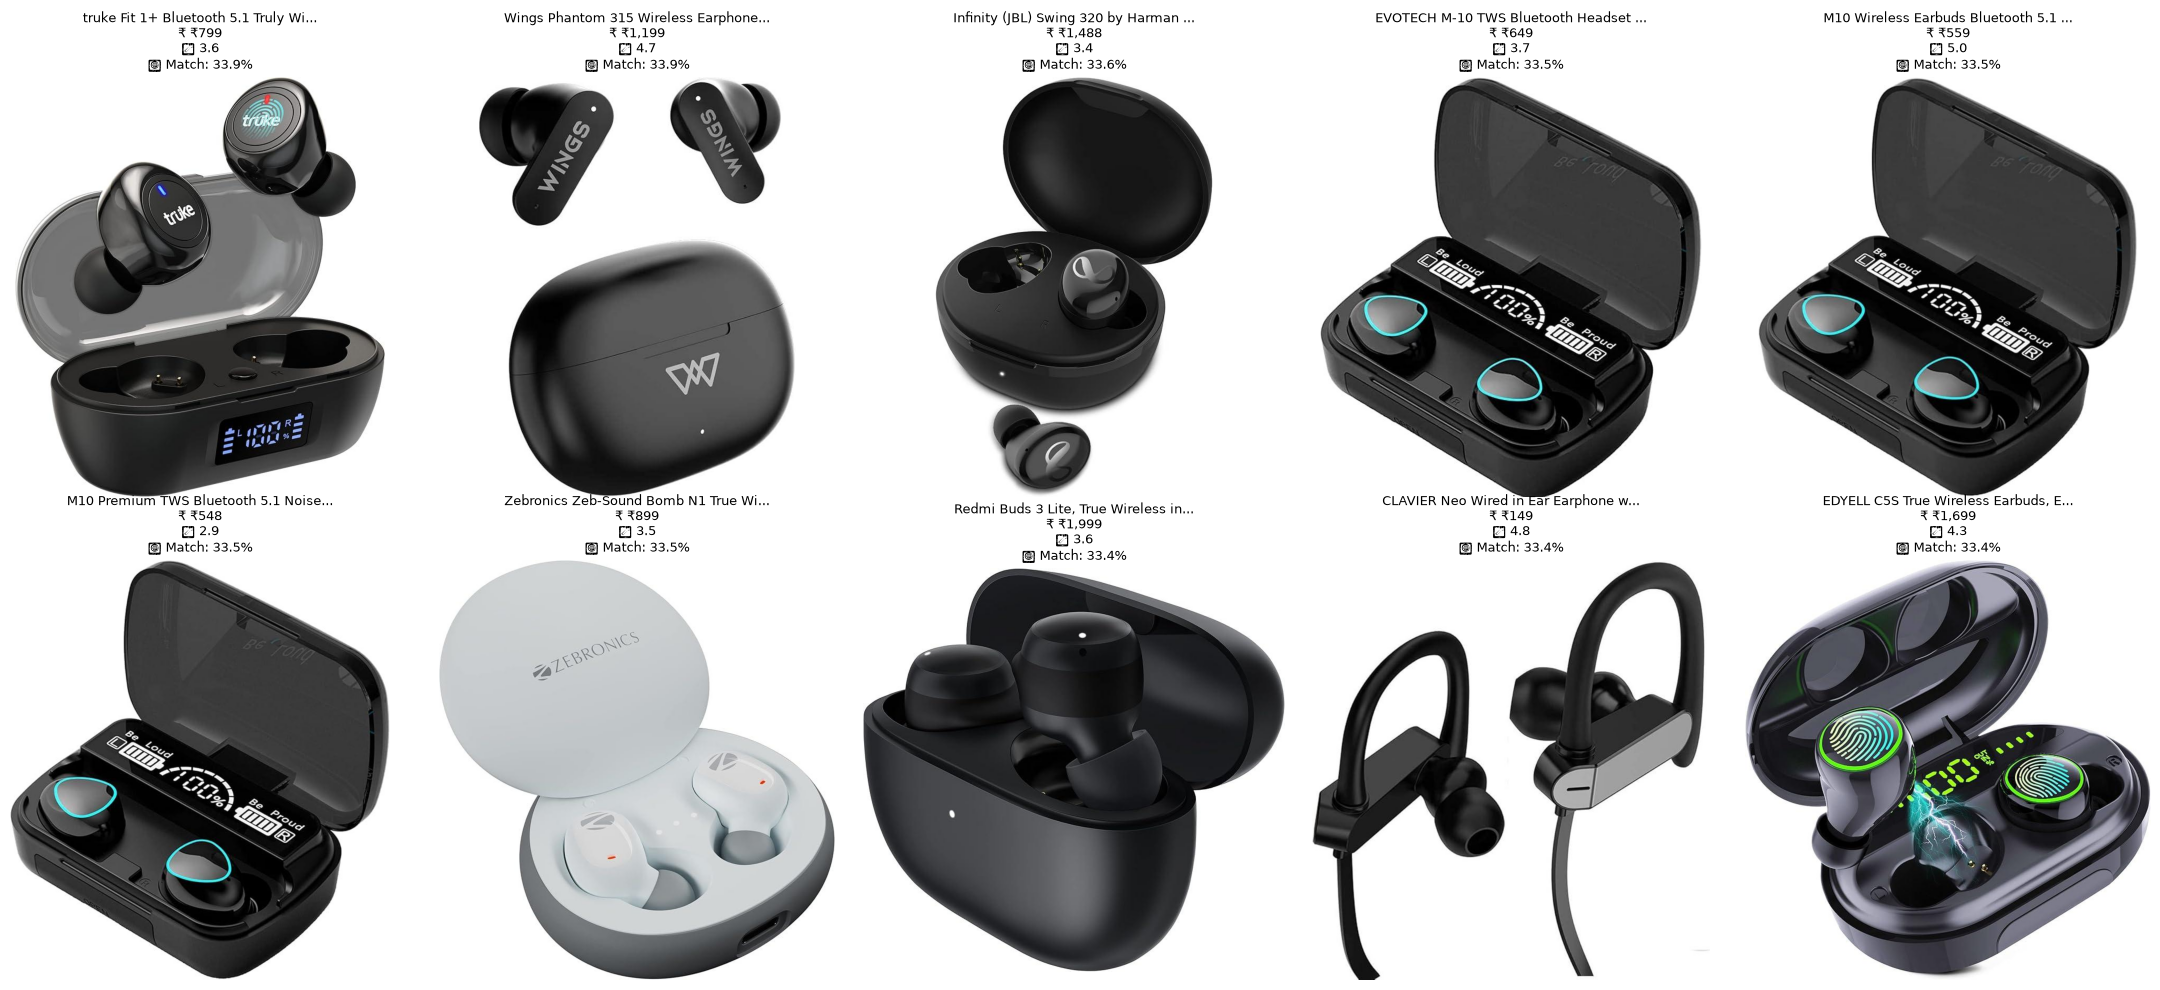

In [18]:
import matplotlib.pyplot as plt
from PIL import Image
import os

image_folder = "../data/images"

fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

for i, idx in enumerate(top_indices):

    image_name = mapping_df.iloc[idx]["image_name"]
    image_path = os.path.join(image_folder, image_name)

    product = recommended_products.iloc[i]

    try:
        img = Image.open(image_path)
        axes[i].imshow(img)
    except Exception:
        axes[i].text(
            0.5,
            0.5,
            "Image\nNot Found",
            ha="center",
            va="center",
            fontsize=12,
        )

    axes[i].axis("off")

    title = (
        product["name"][:35] + "..."
        if len(product["name"]) > 35
        else product["name"]
    )

    axes[i].set_title(
        (
            f"{title}\n"
            f"₹ {product['discount_price']}\n"
            f"⭐ {product['ratings']}\n"
            f"🎯 Match: {product['similarity_score'] * 100:.1f}%"
        ),
        fontsize=9,
    )

plt.tight_layout()
plt.show()

In [19]:
combined_embeddings = np.load(
    "../data/embeddings/combined_embeddings.npy"
)

print(combined_embeddings.shape)

(9599, 512)


In [20]:
query = "wireless bluetooth earbuds"

In [21]:
query = "bluetooth speaker"

In [23]:
products_df = pd.read_csv(
    "../data/processed/cleaned_electronics_products.csv"
)
print(products_df.columns)

Index(['Unnamed: 0', 'name', 'main_category', 'sub_category', 'image', 'link',
       'ratings', 'no_of_ratings', 'discount_price', 'actual_price'],
      dtype='str')


In [24]:
products_df = pd.read_csv(
    "../data/processed/cleaned_electronics_products.csv"
)
products_df.head(3)

,Unnamed: 0,name,main_category,sub_category,image,link,ratings,no_of_ratings,discount_price,actual_price
0,0,"Redmi 10 Power (Power Black, 8GB RAM, 128GB St...","tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/81eM15lVcJ...,https://www.amazon.in/Redmi-Power-Black-128GB-...,4.0,965,"₹10,999","₹18,999"
1,1,"OnePlus Nord CE 2 Lite 5G (Blue Tide, 6GB RAM,...","tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/71AvQd3Vzq...,https://www.amazon.in/OnePlus-Nord-Lite-128GB-...,4.3,"113,956","₹18,999","₹19,999"
2,2,OnePlus Bullets Z2 Bluetooth Wireless in Ear E...,"tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/51UhwaQXCp...,https://www.amazon.in/Oneplus-Bluetooth-Wirele...,4.2,"90,304","₹1,999","₹2,299"


In [27]:
import pandas as pd
import numpy as np

products = pd.read_csv("../data/processed/cleaned_electronics_products.csv")
mapping = pd.read_csv("../data/embeddings/image_mapping.csv")
combined = np.load("../data/embeddings/combined_embeddings.npy")

print("Products:", len(products))
print("Mapping:", len(mapping))
print("Combined Embeddings:", len(combined))

Products: 9600
Mapping: 9599
Combined Embeddings: 9599
